# Project 1: Anomaly Detection in Financial Data
# Using Unsupervised Learning

**Task:** Detect anomalies in financial installment purchase data using unsupervised learning methods.

**Author:** Trầm Tính Ân - 24520074

---


# 1. Load Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_excel('data/Data_finance.xlsx')
print(f"Shape: {df.shape}")
print(f"\nRows: {df.shape[0]}, Columns: {df.shape[1]}")


Shape: (5000, 31)

Rows: 5000, Columns: 31


## 1.1 Calculate INCOME column
Formula: `INCOME = (PERSONAL_INCOME + ADDITIONAL_INCOME + FAMILY_INCOME) - (PERSONAL_EXPENSE + FAMILY_EXPENSE)`


In [2]:
# Calculate INCOME column
df['INCOME'] = (df['PERSONAL_INCOME'] + df['ADDITIONAL_INCOME'] + df['FAMILY_INCOME']) - \
               (df['PERSONAL_EXPENSE'] + df['FAMILY_EXPENSE'])

print("INCOME column calculated.")
print(f"INCOME - Min: {df['INCOME'].min():,.0f}, Max: {df['INCOME'].max():,.0f}, Mean: {df['INCOME'].mean():,.0f}")


INCOME column calculated.
INCOME - Min: -87,000,000, Max: 352,972,000, Mean: 17,441,844


## 1.2 Dataset Information


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   APP_ID                    5000 non-null   int64         
 1   DISBURSALDATE             5000 non-null   datetime64[us]
 2   REPORT_DATE               5000 non-null   datetime64[us]
 3   TERM_TMP                  5000 non-null   int64         
 4   PRODUCT_NAME              5000 non-null   str           
 5   LOANAMOUNT_NOT_INSURANCE  5000 non-null   int64         
 6   INSURANCE_FEE             5000 non-null   int64         
 7   LA                        5000 non-null   int64         
 8   EFF_RATE                  5000 non-null   float64       
 9   TERM                      5000 non-null   int64         
 10  COUNT_TERM_RECEIPT        4909 non-null   float64       
 11  flag term                 4909 non-null   float64       
 12  SUM_RECEIPT_AMT           4909 

In [4]:
# First 5 rows
df.head()


,APP_ID,DISBURSALDATE,REPORT_DATE,TERM_TMP,PRODUCT_NAME,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,...,ADDITIONAL_INCOME,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE,MARITAL_STATUS,EDUCATION,City,ADDRESS_CURRENT_CITY,PROVINCE_CURRENT,INCOME
0,16499318,2017-10-10,2018-10-26,12,FC UP DSA TS SCORE 2 NEW- 762,18000000,990000,18990000,45.0,24,...,0,9600000,20000000,5000000,Other,High School,Tỉnh Yên Bái,Yên Bình,Tỉnh Yên Bái,14400000
1,16490594,2017-10-10,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,10000000,550000,10550000,44.5,12,...,0,7200000,15000000,4000000,Married,High School,Tỉnh Quảng Ninh,Đông Triều,Tỉnh Quảng Ninh,9300000
2,16910227,2017-10-28,2018-10-26,11,FC UP CAT B NEW- 610,25000000,1375000,26375000,47.0,24,...,0,12000000,5200000,1000000,Single,Middle School,Tỉnh Bình Dương,Tân Uyên,Tỉnh Bình Dương,-2618000
3,16355347,2017-10-04,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,30000000,1650000,31650000,44.5,24,...,0,18000000,20000000,6000000,Married,Middle School,Tỉnh An Giang,Phú Tân,Tỉnh An Giang,6000000
4,16705974,2017-10-18,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,20000000,1100000,21100000,44.5,18,...,0,12000000,20000000,7000000,Single,High School,Thành phố Hải Phòng,Vĩnh Bảo,Thành phố Hải Phòng,8000000


---
# 2. Exploratory Data Analysis & Preprocessing

## 2.1 Descriptive Statistics


In [5]:
df.describe()


,APP_ID,DISBURSALDATE,REPORT_DATE,TERM_TMP,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,COUNT_TERM_RECEIPT,...,RESULT_YES/NO,EMI,AGE,Number of Children,PERSONAL_INCOME,ADDITIONAL_INCOME,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE,INCOME
count,5.000000e+03,5000,5000,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4909.000000,...,5000.000000,5.000000e+03,5000.000000,800.000000,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,1.664263e+07,2017-10-16 22:06:14.400000,2018-10-26 00:00:00,12.003200,1.564802e+07,7.934629e+05,1.644148e+07,36.797372,15.046800,8.464046,...,0.727200,1.373196e+06,34.283000,1.760000,8.563299e+06,7.600000e+03,8.464034e+06,2.180893e+07,4.473954e+06,1.744184e+07
min,1.567386e+07,2017-10-01 00:00:00,2018-10-26 00:00:00,11.000000,1.200000e+06,0.000000e+00,1.260000e+06,0.000000,3.000000,1.000000,...,0.000000,2.660000e+05,18.000000,0.000000,2.200000e+06,0.000000e+00,2.000000e+05,2.000000e+06,5.000000e+05,-8.700000e+07
25%,1.649293e+07,2017-10-10 00:00:00,2018-10-26 00:00:00,12.000000,4.940000e+06,2.536380e+05,5.215938e+06,33.500000,6.000000,6.000000,...,0.000000,8.435000e+05,26.000000,1.000000,6.000000e+06,0.000000e+00,1.000000e+06,1.500000e+07,3.000000e+06,1.080000e+07
50%,1.664363e+07,2017-10-17 00:00:00,2018-10-26 00:00:00,12.000000,1.200000e+07,5.500000e+05,1.266000e+07,44.500000,12.000000,9.000000,...,1.000000,1.278378e+06,33.000000,2.000000,8.000000e+06,0.000000e+00,4.900000e+06,2.000000e+07,4.000000e+06,1.700000e+07
75%,1.679488e+07,2017-10-24 00:00:00,2018-10-26 00:00:00,12.000000,2.500000e+07,1.100000e+06,2.637500e+07,47.000000,24.000000,12.000000,...,1.000000,1.785462e+06,41.000000,2.000000,1.000000e+07,0.000000e+00,1.200000e+07,2.500000e+07,5.000000e+06,2.341625e+07
max,1.700631e+07,2017-10-31 00:00:00,2018-10-26 00:00:00,13.000000,7.000000e+07,3.850000e+06,7.385000e+07,85.000000,36.000000,24.000000,...,1.000000,5.632000e+06,99.000000,8.000000,1.000000e+08,5.000000e+06,1.200000e+08,3.580000e+08,3.200000e+07,3.529720e+08
std,1.892634e+05,NaN,NaN,0.059921,1.196323e+07,6.654844e+05,1.255701e+07,21.158261,8.907776,3.369312,...,0.445443,6.898423e+05,9.898874,0.939949,4.176414e+06,1.638524e+05,9.692969e+06,1.124716e+07,2.307437e+06,1.333794e+07


## 2.2 Target Variable Distribution (RESULT_YES/NO)
- 1 = Loan approved (normal)
- 0 = Loan rejected (anomaly)


RESULT_YES/NO Distribution:
RESULT_YES/NO
1    3636
0    1364
Name: count, dtype: int64

Normal (1) ratio: 72.72%
Anomaly (0) ratio: 27.28%


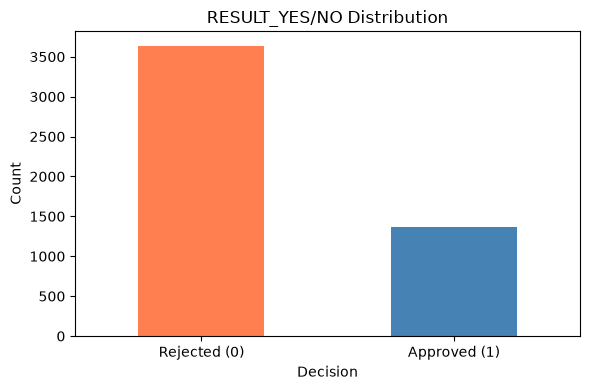

In [6]:
print("RESULT_YES/NO Distribution:")
print(df['RESULT_YES/NO'].value_counts())
print(f"\nNormal (1) ratio: {df['RESULT_YES/NO'].mean():.2%}")
print(f"Anomaly (0) ratio: {1 - df['RESULT_YES/NO'].mean():.2%}")

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
df['RESULT_YES/NO'].value_counts().plot(kind='bar', color=['coral', 'steelblue'], ax=ax)
ax.set_title('RESULT_YES/NO Distribution')
ax.set_xlabel('Decision')
ax.set_ylabel('Count')
ax.set_xticklabels(['Rejected (0)', 'Approved (1)'], rotation=0)
plt.tight_layout()
plt.show()


## 2.3 Check Missing Values


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_info = pd.DataFrame({'Missing': missing, 'Percent (%)': missing_pct})
print("Columns with missing values:")
print(missing_info[missing_info['Missing'] > 0])


Columns with missing values:
                    Missing  Percent (%)
COUNT_TERM_RECEIPT       91         1.82
flag term                91         1.82
SUM_RECEIPT_AMT          91         1.82
Unnamed: 13            4849        96.98
flag loan amt            91         1.82
flag final               91         1.82
Number of Children     4200        84.00


**Observations:**
- `COUNT_TERM_RECEIPT` and `SUM_RECEIPT_AMT` have N/A values → These represent **bad debt** borrowers (borrowed but never repaid).
- `Number of Children` has many missing values → Empty means no children → Fill with 0.
- `Unnamed: 13` is almost entirely missing → Drop it.


## 2.4 Feature Selection

**Columns to drop:**
- `APP_ID`: Just an ID, no analytical value
- `DISBURSALDATE`, `REPORT_DATE`: Date columns, hard to use directly
- `PRODUCT_NAME`: Too many unique values (174), hard to encode effectively
- `City`, `ADDRESS_CURRENT_CITY`, `PROVINCE_CURRENT`: Address info, too many unique values
- `Unnamed: 13`: Almost entirely missing
- `flag term`, `flag loan amt`, `flag final`: Auxiliary columns
- `RESULT_YES/NO`: This is the LABEL, used only for evaluation, NOT for training


In [8]:
# Columns to drop
cols_to_drop = [
    'APP_ID', 'DISBURSALDATE', 'REPORT_DATE', 'PRODUCT_NAME',
    'City', 'ADDRESS_CURRENT_CITY', 'PROVINCE_CURRENT',
    'Unnamed: 13', 'flag term', 'flag loan amt', 'flag final',
    'RESULT_YES/NO'  # Label - only for evaluation
]

# Save labels before dropping
labels = df['RESULT_YES/NO'].copy()

# Create feature dataframe
df_features = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Remaining columns: {df_features.shape[1]}")
print(f"Columns: {df_features.columns.tolist()}")


Remaining columns: 20
Columns: ['TERM_TMP', 'LOANAMOUNT_NOT_INSURANCE', 'INSURANCE_FEE', 'LA', 'EFF_RATE', 'TERM', 'COUNT_TERM_RECEIPT', 'SUM_RECEIPT_AMT', 'EMI', 'GENDER', 'AGE', 'Number of Children', 'PERSONAL_INCOME', 'ADDITIONAL_INCOME', 'PERSONAL_EXPENSE', 'FAMILY_INCOME', 'FAMILY_EXPENSE', 'MARITAL_STATUS', 'EDUCATION', 'INCOME']


## 2.5 Handle Missing Values


In [9]:
# 1. Number of Children: NaN = no children -> Fill with 0
df_features['Number of Children'] = df_features['Number of Children'].fillna(0)

# 2. COUNT_TERM_RECEIPT & SUM_RECEIPT_AMT: NaN = bad debt -> Fill with 0
df_features['COUNT_TERM_RECEIPT'] = df_features['COUNT_TERM_RECEIPT'].fillna(0)
df_features['SUM_RECEIPT_AMT'] = df_features['SUM_RECEIPT_AMT'].fillna(0)

# Verify
print("Missing values after handling:")
print(df_features.isnull().sum().sum(), "missing values remaining")


Missing values after handling:
0 missing values remaining


## 2.6 Encode Categorical Columns

- **GENDER:** F=0, M=1 (binary encoding)
- **MARITAL_STATUS:** LabelEncoder
- **EDUCATION:** Ordinal encoding by education level (low to high)


In [10]:
# GENDER: F=0, M=1
df_features['GENDER'] = df_features['GENDER'].map({'F': 0, 'M': 1})
print("GENDER encoded: F=0, M=1")

# EDUCATION: Ordinal encoding (low -> high)
education_order = {
    'No Education': 0, 'Basic School': 1, 'Middle School': 2,
    'High School': 3, 'Working Cerfiticate': 4, 'College': 5,
    'Bachelor': 6, 'Master Degree': 7
}
df_features['EDUCATION'] = df_features['EDUCATION'].map(education_order)
print(f"EDUCATION encoded: {education_order}")

# MARITAL_STATUS: LabelEncoder
le_marital = LabelEncoder()
df_features['MARITAL_STATUS'] = le_marital.fit_transform(df_features['MARITAL_STATUS'])
print(f"MARITAL_STATUS encoded: {dict(zip(le_marital.classes_, le_marital.transform(le_marital.classes_)))}")

print(f"\nShape after encoding: {df_features.shape}")


GENDER encoded: F=0, M=1
EDUCATION encoded: {'No Education': 0, 'Basic School': 1, 'Middle School': 2, 'High School': 3, 'Working Cerfiticate': 4, 'College': 5, 'Bachelor': 6, 'Master Degree': 7}
MARITAL_STATUS encoded: {'Civil Marriage/live-in': np.int64(0), 'Divorced': np.int64(1), 'Married': np.int64(2), 'Other': np.int64(3), 'Single': np.int64(4)}

Shape after encoding: (5000, 20)


## 2.7 Feature Normalization

Using StandardScaler to bring all features to the same scale (mean=0, std=1). This is crucial for unsupervised learning algorithms.


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

print(f"Shape after scaling: {X_scaled.shape}")
print(f"Mean (should be ~0): {X_scaled.mean(axis=0)[:5].round(4)}")
print(f"Std (should be ~1): {X_scaled.std(axis=0)[:5].round(4)}")


Shape after scaling: (5000, 20)
Mean (should be ~0): [ 0. -0.  0. -0.  0.]
Std (should be ~1): [1. 1. 1. 1. 1.]


## 2.8 Visualize Feature Distributions


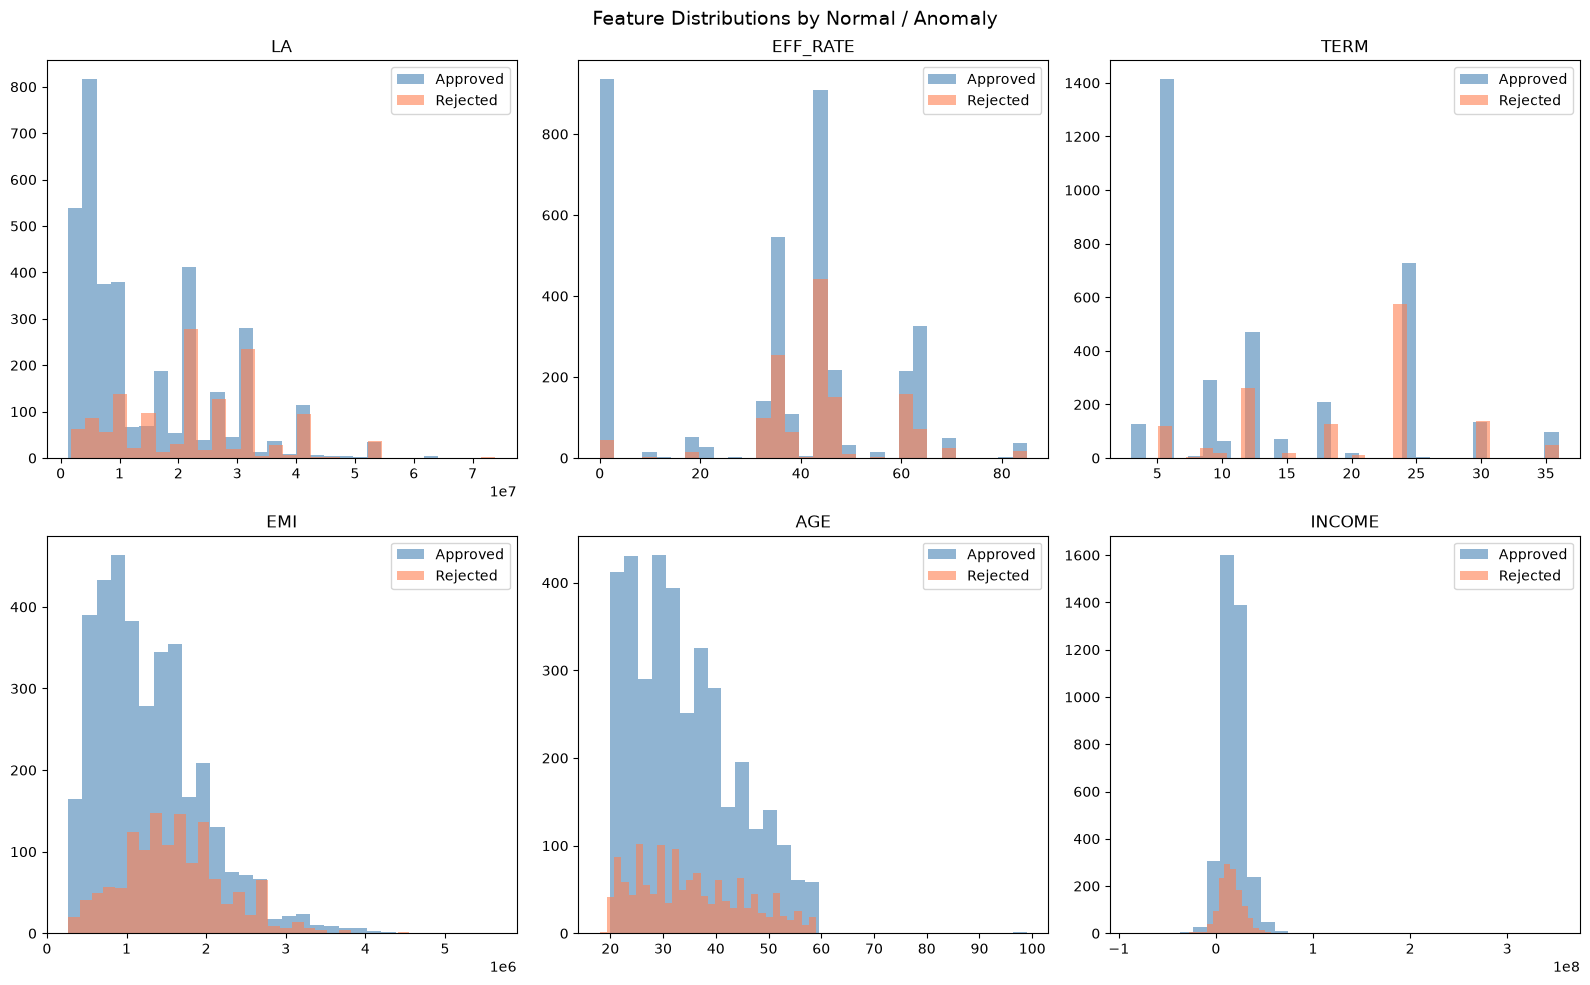

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['LA', 'EFF_RATE', 'TERM', 'EMI', 'AGE', 'INCOME']

for i, feat in enumerate(features_to_plot):
    row, col = i // 3, i % 3
    if feat in df_features.columns:
        for val, color, lbl in [(1, 'steelblue', 'Approved'), (0, 'coral', 'Rejected')]:
            axes[row, col].hist(df[df['RESULT_YES/NO'] == val][feat].dropna(),
                                bins=30, alpha=0.6, color=color, label=lbl)
        axes[row, col].set_title(feat)
        axes[row, col].legend()

plt.suptitle('Feature Distributions by Normal / Anomaly', fontsize=14)
plt.tight_layout()
plt.show()


---
# 3. Build Models

## Important Notes
- Only **unsupervised learning** methods are allowed
- `RESULT_YES/NO` is used only for **evaluation**, NOT for training
- Model output: 1 = normal, 0 = anomaly

## 3.1 Model 1: Isolation Forest

**Isolation Forest** detects anomalies based on the idea that anomalous points are easier to "isolate" than normal points.

**Principle:** Build many random decision trees. Data points that get isolated quickly (require fewer splits) are likely anomalies.


In [13]:
# Anomaly ratio in data
contamination_rate = (labels == 0).sum() / len(labels)
print(f"Actual anomaly ratio: {contamination_rate:.4f} ({contamination_rate:.2%})")

# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination_rate,
    random_state=42,
    n_jobs=-1
)
iso_pred = iso_forest.fit_predict(X_scaled)

# Convert: Isolation Forest returns 1 (normal) and -1 (anomaly)
iso_pred_binary = np.where(iso_pred == 1, 1, 0)

print(f"\nIsolation Forest Results:")
print(f"  Predicted normal (1): {(iso_pred_binary == 1).sum()}")
print(f"  Predicted anomaly (0): {(iso_pred_binary == 0).sum()}")


Actual anomaly ratio: 0.2728 (27.28%)

Isolation Forest Results:
  Predicted normal (1): 3636
  Predicted anomaly (0): 1364


### Evaluate Isolation Forest


MODEL EVALUATION: Isolation Forest
Accuracy:  0.6600
Precision: 0.7662
Recall:    0.7662
F1-Score:  0.7662

Classification Report:
              precision    recall  f1-score   support

 Anomaly (0)       0.38      0.38      0.38      1364
  Normal (1)       0.77      0.77      0.77      3636

    accuracy                           0.66      5000
   macro avg       0.57      0.57      0.57      5000
weighted avg       0.66      0.66      0.66      5000



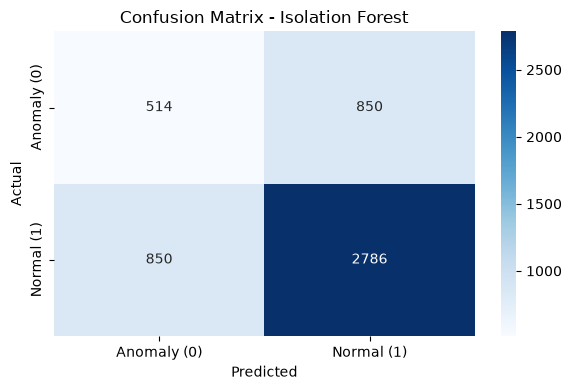

In [14]:
def evaluate_model(y_true, y_pred, model_name):
    """Print evaluation metrics for the model."""
    print(f"{'='*50}")
    print(f"MODEL EVALUATION: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Anomaly (0)', 'Normal (1)']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Anomaly (0)', 'Normal (1)'],
                yticklabels=['Anomaly (0)', 'Normal (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

evaluate_model(labels, iso_pred_binary, "Isolation Forest")


## 3.2 Model 2: Local Outlier Factor (LOF)

**Local Outlier Factor** measures the local density of each data point compared to its neighbors.

**Principle:** If a point has significantly lower density than its surrounding points, it is likely an anomaly.


LOF Results:
  Predicted normal (1): 3636
  Predicted anomaly (0): 1364
MODEL EVALUATION: Local Outlier Factor (LOF)
Accuracy:  0.6332
Precision: 0.7478
Recall:    0.7478
F1-Score:  0.7478

Classification Report:
              precision    recall  f1-score   support

 Anomaly (0)       0.33      0.33      0.33      1364
  Normal (1)       0.75      0.75      0.75      3636

    accuracy                           0.63      5000
   macro avg       0.54      0.54      0.54      5000
weighted avg       0.63      0.63      0.63      5000



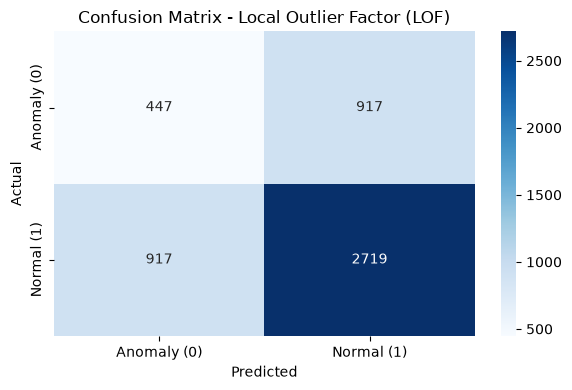

In [15]:
# Train Local Outlier Factor
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=contamination_rate,
    n_jobs=-1
)
lof_pred = lof.fit_predict(X_scaled)

lof_pred_binary = np.where(lof_pred == 1, 1, 0)

print(f"LOF Results:")
print(f"  Predicted normal (1): {(lof_pred_binary == 1).sum()}")
print(f"  Predicted anomaly (0): {(lof_pred_binary == 0).sum()}")

evaluate_model(labels, lof_pred_binary, "Local Outlier Factor (LOF)")


## 3.3 Model 3: One-Class SVM

**One-Class SVM** learns a boundary around "normal" data points.

**Principle:** Find a hyperplane in feature space such that most data lies inside. Points outside the boundary are considered anomalies.


One-Class SVM Results:
  Predicted normal (1): 3634
  Predicted anomaly (0): 1366
MODEL EVALUATION: One-Class SVM
Accuracy:  0.6288
Precision: 0.7449
Recall:    0.7445
F1-Score:  0.7447

Classification Report:
              precision    recall  f1-score   support

 Anomaly (0)       0.32      0.32      0.32      1364
  Normal (1)       0.74      0.74      0.74      3636

    accuracy                           0.63      5000
   macro avg       0.53      0.53      0.53      5000
weighted avg       0.63      0.63      0.63      5000



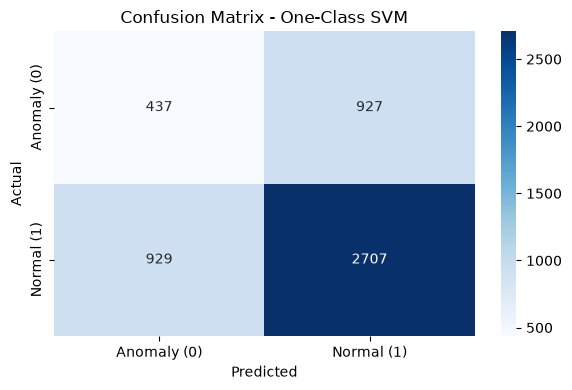

In [16]:
# Train One-Class SVM
oc_svm = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=contamination_rate
)
svm_pred = oc_svm.fit_predict(X_scaled)

svm_pred_binary = np.where(svm_pred == 1, 1, 0)

print(f"One-Class SVM Results:")
print(f"  Predicted normal (1): {(svm_pred_binary == 1).sum()}")
print(f"  Predicted anomaly (0): {(svm_pred_binary == 0).sum()}")

evaluate_model(labels, svm_pred_binary, "One-Class SVM")


---
# 4. Model Comparison


MODEL COMPARISON
               Model  Accuracy  Precision   Recall  F1-Score
    Isolation Forest    0.6600   0.766227 0.766227  0.766227
Local Outlier Factor    0.6332   0.747800 0.747800  0.747800
       One-Class SVM    0.6288   0.744909 0.744499  0.744704


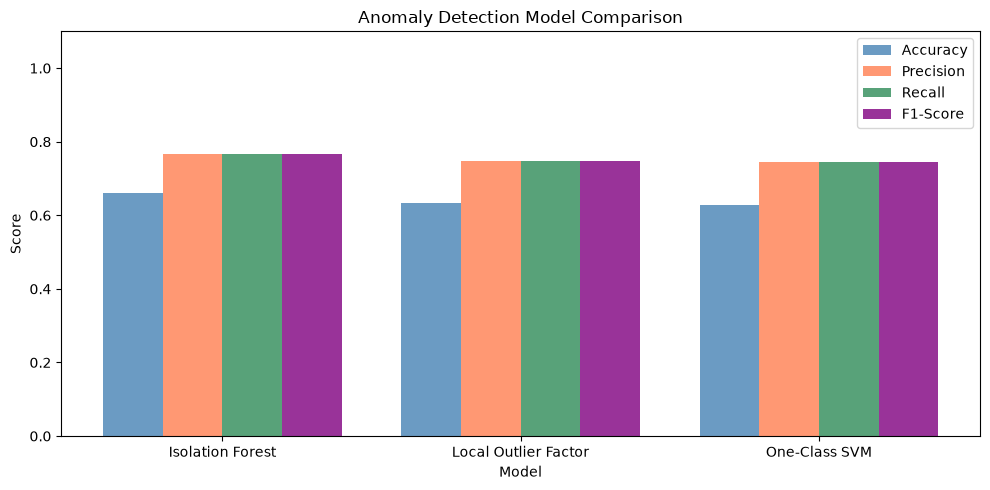

In [17]:
results = {
    'Model': ['Isolation Forest', 'Local Outlier Factor', 'One-Class SVM'],
    'Accuracy': [
        accuracy_score(labels, iso_pred_binary),
        accuracy_score(labels, lof_pred_binary),
        accuracy_score(labels, svm_pred_binary)
    ],
    'Precision': [
        precision_score(labels, iso_pred_binary, zero_division=0),
        precision_score(labels, lof_pred_binary, zero_division=0),
        precision_score(labels, svm_pred_binary, zero_division=0)
    ],
    'Recall': [
        recall_score(labels, iso_pred_binary, zero_division=0),
        recall_score(labels, lof_pred_binary, zero_division=0),
        recall_score(labels, svm_pred_binary, zero_division=0)
    ],
    'F1-Score': [
        f1_score(labels, iso_pred_binary, zero_division=0),
        f1_score(labels, lof_pred_binary, zero_division=0),
        f1_score(labels, svm_pred_binary, zero_division=0)
    ]
}

results_df = pd.DataFrame(results)
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results['Model']))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'coral', 'seagreen', 'purple']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results[metric], width, label=metric, color=color, alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Anomaly Detection Model Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results['Model'])
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()


---
# 5. Conclusion

## Key Findings
- Unsupervised learning methods can detect financial anomalies to a reasonable degree **without labels**.
- **Isolation Forest** typically performs best for anomaly detection tasks as it was specifically designed for this purpose.
- **LOF** works well when anomalies are concentrated in low-density regions.
- **One-Class SVM** finds more complex decision boundaries but is computationally expensive.

## Limitations
- Unsupervised learning does not use labels, so it cannot achieve the same performance as supervised learning.
- The contamination rate needs to be estimated beforehand, which affects results.
- Results heavily depend on feature selection and preprocessing.

## Conclusion
Unsupervised anomaly detection models can provide preliminary credit risk assessment. However, real-world applications would require domain knowledge and more advanced techniques.
